Notebook for data acquisition and running of LSTM algorithm on simulated data 

In [1]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# label maker and datafile reader for my filename conventions 
def labelmaker(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_' + str(sp_density) + 'spd_' + str(t_density) + 'td_n' + str(noise)
    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_results' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile

def datapull(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''Returns data tensors for the given filenames'''
    datafile, labelfile, sourcefile = labelmaker(events, sp_density, t_density, noise, filename, folder)

    data = []
    with open(datafile, 'r') as f:
        for line in f:
            values = [float(v) for v in line.strip().split(',') if v.strip()]  # Convert to float

            if len(values) % 3 != 0:
                print(f"Warning: Skipping malformed row with {len(values)} values (not a multiple of 3)")
                continue  # Skip malformed rows
            
            coords = torch.tensor(values).reshape(-1, 3)  # Convert to (N, 3) tensor
            data.append(coords)  # Store as a tensor

    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    labels = torch.tensor(labels)

    columns = ['x[px]', 'y[px]', 't[s]']
    sourceread = pd.read_csv(sourcefile)
    sources = np.array(sourceread[columns])
    sources = torch.tensor(sources)

    return data, labels, sources
            


In [3]:
# 1. Data Acquisition

# 1.1. Read files 
data, train_labels, train_sources = datapull(filename='100ev_n0')
train_labels = train_labels.to(torch.float32)
train_sources = train_sources.to(torch.float32)

train_lengths = torch.tensor([len(event) for event in data])


#pad sequences to the longest event length
train_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
train_data = train_data.to(torch.float32)

#-------#
data, test_labels, test_sources = datapull(filename='25ev_n0')
test_labels = test_labels.to(torch.float32)
test_sources = test_sources.to(torch.float32)

test_lengths = torch.tensor([len(event) for event in data])

#padding 
test_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
test_data = test_data.to(torch.float32)



In [4]:
train_lengths

tensor([ 34,  74,  21,  79,  74,  92,  12,  50,  20,  62,  82,  26,  35,  44,
         42,  77,  65,  32,  37,  73,  62,   7,  42,  31,  64,  72,  63,  27,
         11,  35,  36,  65, 106,  84,  71,  62,  40,  47,  12, 120,  64,  18,
         55,  16,  18,  40,  74,  35,  21,  10,  24,  29,  81,  13,  16,  26,
         63, 120,  85,  17,  57,  17,  45,   4,  28,  92,  53,  34,   9,  31,
         53,  19,  17,  30,  75,  40,  94,  27,  50,  63,  28,  54,  47,  61,
         38,  24,  35,  30,  59,   4,  56,  39,  32,  15,  14,  45,  19,  80,
         85,  11])

In [5]:
# LSTM Model Definition 

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers 

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        packed_x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[torch.arange(out.size(0)), lengths-1]
        out = self.fc(last_outputs)

        return out

class sourceLSTM(nn.Module): 
    def __init__(self, input_size=3, hidden_size=32, num_layers=4, dropout=0.2):
        super(sourceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x, lengths): 
        x_packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_output, (hidden, cell) = self.lstm(x_packed)

        output = hidden[-1]
        output = self.fc(output)

        return output


In [6]:
### custom loss to include a penalty for sources clustered together
threshold = 0.1

def MSE_penalty(y_pred, y_true): 
    v_penalty = -torch.sum(torch.var(y_pred, dim=0))

    y_pred = y_pred.detach().numpy()
    y_true = np.array(y_true)

    mse = (np.mean((y_pred - y_true)**2))*1e-5

    return v_penalty + mse

In [12]:
model = sourceLSTM()
loss_fn = nn.MSELoss() #MSE_penalty() #nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Epoch:1
Train Loss:0.004034627694636583
Test Loss:0.05632255598902702
Epoch:2
Train Loss:0.004076058976352215
Test Loss:0.05771694704890251
Epoch:3
Train Loss:0.004422723315656185
Test Loss:0.05464929714798927
Epoch:4
Train Loss:0.004340250510722399
Test Loss:0.05418696627020836
Epoch:5
Train Loss:0.0036717085167765617
Test Loss:0.05628761276602745
Epoch:6
Train Loss:0.003910345956683159
Test Loss:0.057765018194913864
Epoch:7
Train Loss:0.004709125030785799
Test Loss:0.055780068039894104
Epoch:8
Train Loss:0.0035715452395379543
Test Loss:0.0577138215303421
Epoch:9
Train Loss:0.0039721340872347355
Test Loss:0.06175924837589264
Epoch:10
Train Loss:0.003887865226715803
Test Loss:0.06447464227676392
Epoch:11
Train Loss:0.004418799187988043
Test Loss:0.06008084490895271
Epoch:12
Train Loss:0.003599832532927394
Test Loss:0.055720988661050797
Epoch:13
Train Loss:0.003583076875656843
Test Loss:0.05704254284501076
Epoch:14
Train Loss:0.003730769967660308
Test Loss:0.05752343311905861
Epoch:15
T

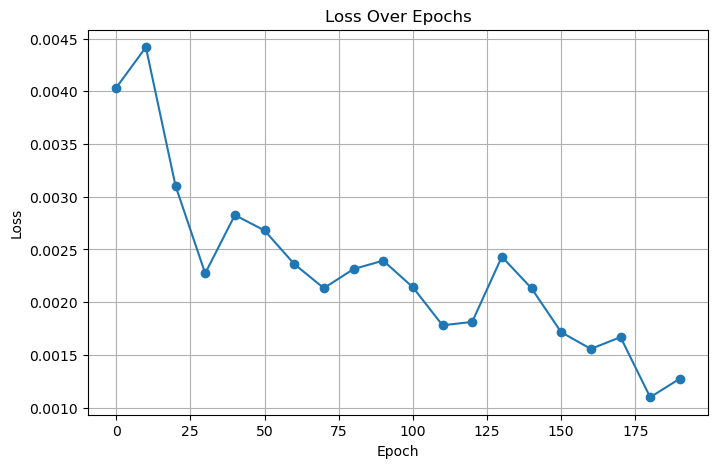

In [23]:
# Training and Evaluation Loop 

epochs = 200 
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(train_data, train_lengths)
    loss = loss_fn(y_pred, train_sources)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:  # Store every tenth epoch
            loss = loss.detach().numpy()
            losses.append((epoch, loss))

    model.eval()
    with torch.no_grad():
        y_pred_test = model(test_data, test_lengths)
        test_loss = loss_fn(y_pred_test, test_sources)
    
    print(f"Epoch:{epoch +1}")
    print(f"Train Loss:{loss}")
    print(f"Test Loss:{test_loss}")


epochs, loss_values = zip(*losses)  # Unpacking the list of tuples
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.grid()
plt.savefig('losses_64hl_4l_0.2do_mseP.png')



In [25]:
y_pred = model(train_data, train_lengths)
torch.mean(torch.var(y_pred, dim=0))

tensor(0.0846, grad_fn=<MeanBackward0>)

In [26]:
predictions = model(test_data, test_lengths)
predictions = predictions.detach().numpy()

In [27]:
len(predictions), len(test_sources)

(25, 25)

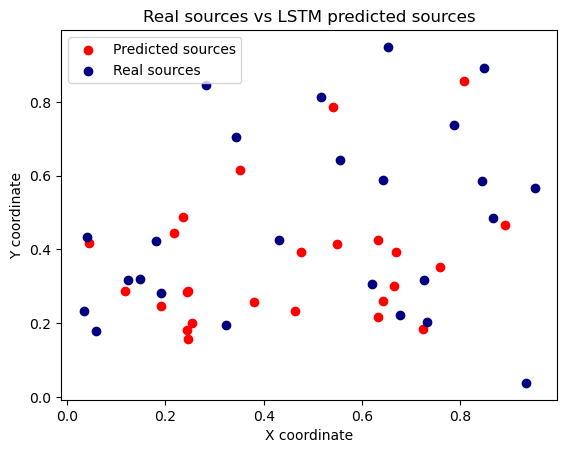

In [ ]:

plt.scatter(predictions[:,2], predictions[:,1], c='red', label='Predicted sources')
plt.scatter(test_sources[:,2], test_sources[:,1], c='navy', label='Real sources')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("X coordinate")
plt.legend()